# 🌍 GeoSpatial Agent — End-to-End Test Notebook

This notebook runs the full LangGraph agent pipeline and inspects each flow:

| # | Flow | Intent | Trigger |
|---|---|---|---|
| 1 | Score a site | `score_site` | `site_input` + `user_weights` |
| 2 | Advisory + Score | `advise_weights` | `site_input`, no weights |
| 3 | Compare sites | `compare_sites` | `site_input` + `comparison_sites` |
| 4 | Find hotspots | `find_hotspots` | No `site_input`, `state_name` |
| 5 | Explain result | `explain_result` | `site_input` + `request_explanation=True` |
| 6 | Error handling | `error` | Invalid coordinates |

---
## 0. Setup & Imports

In [1]:
import sys
import uuid
import os

# Ensure project root is on the path
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT}")

Project root: e:\geo_site_v2


In [2]:
# Core imports
from core.config import get_settings
from core.logger import setup_logging, get_logger

# Initialize logging
settings = get_settings()
setup_logging(log_level="DEBUG")
logger = get_logger("agent-test")

print(f"Database URL: {settings.database_url[:40]}...")
print(f"LLM Provider: {settings.llm_provider} / {settings.llm_model}")
print(f"App Env: {settings.app_env}")

Database URL: postgresql+asyncpg://postgres:codeYK%402...
LLM Provider: groq / llama-3.3-70b-versatile
App Env: development


In [3]:
# Agent & model imports
from agents.graph import get_compiled_graph, build_graph
from models.site import SiteInput, SiteFeatures, PrecomputedScores, SiteScore, ScoreBreakdown
from models.weights import WeightConfig
from scoring.weights import USE_CASE_WEIGHTS, VALID_USE_CASES
from tools.config_tools import get_default_weights

print(f"Valid use cases: {VALID_USE_CASES}")
print(f"Graph built successfully ✓")

Valid use cases: ['retail', 'ev_charging', 'warehouse', 'telecom', 'renewable']
Graph built successfully ✓


---
## Helper: Run Graph & Print Results

In [4]:
from pprint import pprint

async def run_agent(initial_state: dict, label: str = "Test") -> dict:
    """
    Run the compiled graph with the given initial state.
    Prints a formatted summary of the results.
    """
    print(f"\n{'='*60}")
    print(f"  🚀 {label}")
    print(f"{'='*60}")
    
    # Add thread_id if not present
    if "thread_id" not in initial_state:
        initial_state["thread_id"] = str(uuid.uuid4())
    
    compiled = get_compiled_graph()
    config = {"configurable": {"thread_id": initial_state["thread_id"]}}
    
    try:
        result = await compiled.ainvoke(initial_state, config=config)
    except Exception as exc:
        print(f"\n  ❌ Graph execution raised: {exc}")
        return {"error": str(exc)}
    
    # Print summary
    print(f"\n  Intent:       {result.get('intent', 'N/A')}")
    print(f"  Current Node: {result.get('current_node', 'N/A')}")
    print(f"  Error:        {result.get('error', 'None')}")
    
    if result.get('final_score') is not None:
        score = result['final_score']
        bar_filled = int(score / 100 * 20)
        bar = '▓' * bar_filled + '░' * (20 - bar_filled)
        print(f"\n  📊 Site Readiness Score: {score:.1f} / 100  {bar}")
    
    if result.get('score_breakdown'):
        bd = result['score_breakdown']
        print(f"\n  Strengths:  {bd.strengths}")
        print(f"  Weaknesses: {bd.weaknesses}")
        print(f"\n  Contributions:")
        for dim, c in bd.contributions.items():
            print(f"    {dim:30s} raw={c.raw:5.1f}  w={c.weight:.2f}  contrib={c.contribution:5.1f}  rank=#{c.rank}")
    
    if result.get('comparison_results'):
        print(f"\n  🔄 Comparison Results ({len(result['comparison_results'])} sites):")
        for i, site in enumerate(result['comparison_results'], 1):
            print(f"    #{i} {site.id} — score={site.site_readiness_score:.1f}  ({site.lat:.4f}, {site.lng:.4f})")
    
    if result.get('hotspot_results'):
        print(f"\n  🔥 Hotspot Results ({len(result['hotspot_results'])} sites):")
        for i, hs in enumerate(result['hotspot_results'], 1):
            print(f"    #{i} {hs.id} — {hs.district}, {hs.state} — score={hs.site_readiness_score:.1f}")
    
    if result.get('advisory_text'):
        print(f"\n  💡 Advisory: {result['advisory_text'][:200]}")
    
    if result.get('insight_text'):
        print(f"\n  🧠 Insight: {result['insight_text'][:300]}")
    
    if result.get('recommended_weights'):
        rw = result['recommended_weights']
        print(f"\n  ⚖️  Recommended Weights: {rw.model_dump()}")
    
    print(f"\n{'='*60}\n")
    return result

---
## 1. 🎯 Flow 1 — Score a Single Site

**Intent: `score_site`** — user provides lat/lng + weights.  
Path: `orchestrator → fetch_features → fetch_scores → compute_score → explainability → insight → END`

In [5]:
result_score = await run_agent(
    initial_state={
        "use_case": "retail",
        "site_input": SiteInput(lat=23.0225, lng=72.5714),
        "user_weights": get_default_weights("retail"),
    },
    label="Flow 1: Score a Single Site (Ahmedabad — Retail)"
)


  🚀 Flow 1: Score a Single Site (Ahmedabad — Retail)
2026-04-12 02:15:01 | INFO     | agents.orchestrator | Orchestrator node invoked
2026-04-12 02:15:01 | INFO     | agents.orchestrator | Intent detected: score_site
2026-04-12 02:15:02 | INFO     | core.database | Database engine created [pool_size=10, max_overflow=20]
2026-04-12 02:15:02 | INFO     | tools.site_tools | Fetching site features for lat=23.0225, lng=72.5714
2026-04-12 02:15:02,204 INFO sqlalchemy.engine.Engine select pg_catalog.version()
2026-04-12 02:15:02 | INFO     | sqlalchemy.engine.Engine | select pg_catalog.version()
2026-04-12 02:15:02,204 INFO sqlalchemy.engine.Engine [raw sql] ()
2026-04-12 02:15:02 | INFO     | sqlalchemy.engine.Engine | [raw sql] ()
2026-04-12 02:15:02,243 INFO sqlalchemy.engine.Engine select current_schema()
2026-04-12 02:15:02 | INFO     | sqlalchemy.engine.Engine | select current_schema()
2026-04-12 02:15:02,248 INFO sqlalchemy.engine.Engine [raw sql] ()
2026-04-12 02:15:02 | INFO     | s

---
## 2. 💡 Flow 2 — Advisory + Score (No Weights Provided)

**Intent: `advise_weights`** — user provides only lat/lng + use_case, no weights.  
Path: `orchestrator → advisory (LLM) → fetch_features → fetch_scores → compute_score → explainability → insight → END`

In [6]:
result_advisory = await run_agent(
    initial_state={
        "use_case": "ev_charging",
        "site_input": SiteInput(lat=19.0760, lng=72.8777),  # Mumbai
        # NOTE: No user_weights — triggers advisory node
    },
    label="Flow 2: Advisory + Score (Mumbai — EV Charging, no weights)"
)


  🚀 Flow 2: Advisory + Score (Mumbai — EV Charging, no weights)
2026-04-12 02:16:04 | INFO     | agents.orchestrator | Orchestrator node invoked
2026-04-12 02:16:04 | INFO     | agents.orchestrator | Intent detected: advise_weights
2026-04-12 02:16:05 | INFO     | agents.advisory | Advisory LLM call started for use_case=ev_charging
2026-04-12 02:16:05 | INFO     | httpx | HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-04-12 02:16:05 | INFO     | agents.advisory | Advisory weights recommended: {'demand_score': 0.3, 'accessibility_score': 0.2, 'competition_score': 0.1, 'suitability_score': 0.1, 'risk_score': 0.1, 'infrastructure_score': 0.2}
2026-04-12 02:16:05 | INFO     | tools.site_tools | Fetching site features for lat=19.0760, lng=72.8777
2026-04-12 02:16:05,992 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-04-12 02:16:05 | INFO     | sqlalchemy.engine.Engine | BEGIN (implicit)
2026-04-12 02:16:05,995 INFO sqlalchemy.engine.Engine 
 

---
## 3. 🔄 Flow 3 — Compare Multiple Sites

**Intent: `compare_sites`** — user provides primary site + comparison sites.  
Path: `orchestrator → fetch_features → fetch_scores → compute_score (scores all) → explainability → insight → END`

In [7]:
result_compare = await run_agent(
    initial_state={
        "use_case": "warehouse",
        "site_input": SiteInput(lat=23.0225, lng=72.5714),  # Ahmedabad
        "user_weights": get_default_weights("warehouse"),
        "comparison_sites": [
            SiteInput(lat=19.0760, lng=72.8777),  # Mumbai
            SiteInput(lat=12.9716, lng=77.5946),  # Bangalore
        ],
    },
    label="Flow 3: Compare Sites (Ahmedabad vs Mumbai vs Bangalore — Warehouse)"
)


  🚀 Flow 3: Compare Sites (Ahmedabad vs Mumbai vs Bangalore — Warehouse)
2026-04-12 02:17:33 | INFO     | agents.orchestrator | Orchestrator node invoked
2026-04-12 02:17:33 | INFO     | agents.orchestrator | Intent detected: compare_sites
2026-04-12 02:17:33 | INFO     | tools.site_tools | Fetching site features for lat=23.0225, lng=72.5714
2026-04-12 02:17:33,484 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-04-12 02:17:33 | INFO     | sqlalchemy.engine.Engine | BEGIN (implicit)
2026-04-12 02:17:33,486 INFO sqlalchemy.engine.Engine 
        SELECT *
        FROM site_features
        ORDER BY geom <-> ST_SetSRID(ST_MakePoint($1, $2), 4326)
        LIMIT 1;
    
2026-04-12 02:17:33 | INFO     | sqlalchemy.engine.Engine | 
        SELECT *
        FROM site_features
        ORDER BY geom <-> ST_SetSRID(ST_MakePoint($1, $2), 4326)
        LIMIT 1;
    
2026-04-12 02:17:33,490 INFO sqlalchemy.engine.Engine [cached since 151.2s ago] (72.5714, 23.0225)
2026-04-12 02:17:33 | INFO    

---
## 4. 🔥 Flow 4 — Find Hotspots in a State

**Intent: `find_hotspots`** — no site_input, just state_name.  
Path: `orchestrator → geospatial → insight → END`

In [8]:
result_hotspots = await run_agent(
    initial_state={
        "use_case": "retail",
        "site_input": None,  # No site → triggers hotspot flow
        "user_weights": get_default_weights("retail"),
        "state_name": "Gujarat",
    },
    label="Flow 4: Find Hotspots (Gujarat — Retail)"
)


  🚀 Flow 4: Find Hotspots (Gujarat — Retail)
2026-04-12 02:18:13 | INFO     | agents.orchestrator | Orchestrator node invoked
2026-04-12 02:18:13 | INFO     | agents.orchestrator | Intent detected: find_hotspots
2026-04-12 02:18:13,814 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-04-12 02:18:13 | INFO     | sqlalchemy.engine.Engine | BEGIN (implicit)
2026-04-12 02:18:13,816 INFO sqlalchemy.engine.Engine 
        SELECT id, latitude, longitude, state, district,
               demand_score, accessibility_score, competition_score,
               suitability_score, risk_score, infrastructure_score
        FROM site_features
        WHERE LOWER(state) = LOWER($1)
          AND demand_score IS NOT NULL
        
2026-04-12 02:18:13 | INFO     | sqlalchemy.engine.Engine | 
        SELECT id, latitude, longitude, state, district,
               demand_score, accessibility_score, competition_score,
               suitability_score, risk_score, infrastructure_score
        FROM site_featu

---
## 5. 📝 Flow 5 — Explain a Score in Detail

**Intent: `explain_result`** — same as score but `request_explanation=True`.  
Path: `orchestrator → fetch_features → fetch_scores → explainability → insight → END`

In [ ]:
result_explain = await run_agent(
    initial_state={
        "use_case": "telecom",
        "site_input": SiteInput(lat=28.6139, lng=77.2090),  # Delhi
        "user_weights": get_default_weights("telecom"),
        "request_explanation": True,
    },
    label="Flow 5: Explain Score (Delhi — Telecom)"
)

---
## 6. ❌ Flow 6 — Error Handling (Invalid Coordinates)

**Intent: `error`** — coordinates outside India bounds.  
Path: `orchestrator → error_handler → END`

In [9]:
result_error = await run_agent(
    initial_state={
        "use_case": "retail",
        "site_input": SiteInput(lat=51.5074, lng=-0.1278),  # London — outside India
        "user_weights": get_default_weights("retail"),
    },
    label="Flow 6: Error — Invalid Coordinates (London)"
)


  🚀 Flow 6: Error — Invalid Coordinates (London)
2026-04-12 02:20:47 | INFO     | agents.orchestrator | Orchestrator node invoked
2026-04-12 02:20:47 | ERROR    | agents.orchestrator | Orchestrator validation error: Coordinates (51.5074, -0.1278) are outside India bounds (lat: -8 to 37, lng: 68 to 97)

  Intent:       error
  Current Node: error_handler
  Error:        Coordinates (51.5074, -0.1278) are outside India bounds (lat: -8 to 37, lng: 68 to 97)

  🧠 Insight: ⚠ Error: Coordinates (51.5074, -0.1278) are outside India bounds (lat: -8 to 37, lng: 68 to 97)




---
## 7. 🔬 Inspect Individual Nodes

Test individual tools/nodes directly without running the full graph.

### 7a. Test PostGIS Nearest-Site Lookup

In [10]:
from core.database import get_session_factory
from tools.site_tools import fetch_site_features, fetch_precomputed_scores

factory = get_session_factory()

async with factory() as db:
    # Fetch nearest site to Ahmedabad
    features = await fetch_site_features(lat=23.0225, lng=72.5714, db=db)
    print(f"Nearest site ID: {features.id}")
    print(f"Location: {features.state}, {features.district}")
    print(f"Coordinates: ({features.latitude}, {features.longitude})")
    print(f"Population density: {features.population_density}")
    print(f"POI count (1km): {features.poi_count_1km}")
    print(f"Road density: {features.road_density}")

2026-04-12 02:21:03 | INFO     | tools.site_tools | Fetching site features for lat=23.0225, lng=72.5714
2026-04-12 02:21:03,176 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-04-12 02:21:03 | INFO     | sqlalchemy.engine.Engine | BEGIN (implicit)
2026-04-12 02:21:03,178 INFO sqlalchemy.engine.Engine 
        SELECT *
        FROM site_features
        ORDER BY geom <-> ST_SetSRID(ST_MakePoint($1, $2), 4326)
        LIMIT 1;
    
2026-04-12 02:21:03 | INFO     | sqlalchemy.engine.Engine | 
        SELECT *
        FROM site_features
        ORDER BY geom <-> ST_SetSRID(ST_MakePoint($1, $2), 4326)
        LIMIT 1;
    
2026-04-12 02:21:03,182 INFO sqlalchemy.engine.Engine [cached since 360.9s ago] (72.5714, 23.0225)
2026-04-12 02:21:03 | INFO     | sqlalchemy.engine.Engine | [cached since 360.9s ago] (72.5714, 23.0225)
2026-04-12 02:21:03 | INFO     | tools.site_tools | Site features loaded for IND_0099352
Nearest site ID: IND_0099352
Location: Gujarat, Ahmadabad
Coordinates: (23.01

### 7b. Test Precomputed Scores Fetch

In [11]:
async with factory() as db:
    scores = await fetch_precomputed_scores(site_id=features.id, db=db)
    print(f"Site: {scores.id}")
    print(f"Demand Score:          {scores.demand_score:.1f}")
    print(f"Accessibility Score:   {scores.accessibility_score:.1f}")
    print(f"Competition Score:     {scores.competition_score:.1f}")
    print(f"Suitability Score:     {scores.suitability_score:.1f}")
    print(f"Risk Score:            {scores.risk_score:.1f}")
    print(f"Infrastructure Score:  {scores.infrastructure_score:.1f}")

2026-04-12 02:21:28,490 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-04-12 02:21:28 | INFO     | sqlalchemy.engine.Engine | BEGIN (implicit)
2026-04-12 02:21:28,492 INFO sqlalchemy.engine.Engine 
        SELECT id,
               demand_score,
               accessibility_score,
               competition_score,
               suitability_score,
               risk_score,
               infrastructure_score
        FROM site_features
        WHERE id = $1
        LIMIT 1
        
2026-04-12 02:21:28 | INFO     | sqlalchemy.engine.Engine | 
        SELECT id,
               demand_score,
               accessibility_score,
               competition_score,
               suitability_score,
               risk_score,
               infrastructure_score
        FROM site_features
        WHERE id = $1
        LIMIT 1
        
2026-04-12 02:21:28,498 INFO sqlalchemy.engine.Engine [cached since 385.9s ago] ('IND_0099352',)
2026-04-12 02:21:28 | INFO     | sqlalchemy.engine.Engine | [

### 7c. Test Scoring Engine (Deterministic)

In [12]:
from scoring.engine import compute_final_score

weights = get_default_weights("retail")

site_score = compute_final_score(
    precomputed_scores=scores,
    user_weights=weights,
    lat=features.latitude,
    lng=features.longitude,
)

print(f"Site: {site_score.id}")
print(f"Final Score: {site_score.site_readiness_score:.1f}")
print(f"\nContributions:")
for dim, val in site_score.contributions.items():
    print(f"  {dim:30s} = {val:.2f}")

2026-04-12 02:21:36 | INFO     | scoring.engine | Score computed for IND_0099352: 63.77 (contributions: {'demand_score': 20.09, 'accessibility_score': 20.0, 'competition_score': 0.0, 'suitability_score': 10.0, 'risk_score': 5.04, 'infrastructure_score': 8.64})
Site: IND_0099352
Final Score: 63.8

Contributions:
  demand_score                   = 20.09
  accessibility_score            = 20.00
  competition_score              = 0.00
  suitability_score              = 10.00
  risk_score                     = 5.04
  infrastructure_score           = 8.64


### 7d. Test Explainability Breakdown

In [13]:
from tools.explainability_tools import score_breakdown

breakdown = score_breakdown(site_score)

print(f"Score: {breakdown.site_readiness_score:.1f}")
print(f"Strengths:  {breakdown.strengths}")
print(f"Weaknesses: {breakdown.weaknesses}")
print(f"\nRanked contributions:")
for dim, c in breakdown.contributions.items():
    bar = '█' * max(1, int(c.contribution / 5))
    print(f"  #{c.rank} {dim:30s} raw={c.raw:5.1f} × {c.weight:.2f} = {c.contribution:5.1f}  {bar}")

Score: 63.8
Strengths:  ['demand_score', 'accessibility_score']
Weaknesses: ['competition_score', 'risk_score']

Ranked contributions:
  #1 demand_score                   raw= 67.0 × 0.30 =  20.1  ████
  #2 accessibility_score            raw=100.0 × 0.20 =  20.0  ████
  #3 suitability_score              raw=100.0 × 0.10 =  10.0  ██
  #4 infrastructure_score           raw= 86.4 × 0.10 =   8.6  █
  #5 risk_score                     raw= 50.4 × 0.10 =   5.0  █
  #6 competition_score              raw=  0.0 × 0.20 =   0.0  █


### 7e. Test What-If Analysis

In [14]:
from tools.explainability_tools import what_if_analysis

current_weights = get_default_weights("retail")
modified_weights = WeightConfig(
    demand_score=0.15,
    accessibility_score=0.15,
    competition_score=0.10,
    suitability_score=0.10,
    risk_score=0.10,
    infrastructure_score=0.40,  # Heavy infra emphasis
)

whatif = what_if_analysis(
    precomputed_scores=scores,
    current_weights=current_weights,
    modified_weights=modified_weights,
)

print(f"Original Score:  {whatif.original_score:.1f}")
print(f"Modified Score:  {whatif.modified_score:.1f}")
print(f"Delta:           {whatif.delta:+.1f}")
print(f"\nPer-dimension delta:")
for dim, delta in whatif.dimension_deltas.items():
    arrow = '↑' if delta > 0 else '↓' if delta < 0 else '→'
    print(f"  {dim:30s} {delta:+.2f} {arrow}")

2026-04-12 02:23:29 | INFO     | scoring.engine | Score computed for IND_0099352: 63.77 (contributions: {'demand_score': 20.09, 'accessibility_score': 20.0, 'competition_score': 0.0, 'suitability_score': 10.0, 'risk_score': 5.04, 'infrastructure_score': 8.64})
2026-04-12 02:23:29 | INFO     | scoring.engine | Score computed for IND_0099352: 74.63 (contributions: {'demand_score': 10.05, 'accessibility_score': 15.0, 'competition_score': 0.0, 'suitability_score': 10.0, 'risk_score': 5.04, 'infrastructure_score': 34.55})
Original Score:  63.8
Modified Score:  74.6
Delta:           +10.9

Per-dimension delta:
  demand_score                   -10.04 ↓
  accessibility_score            -5.00 ↓
  competition_score              +0.00 →
  suitability_score              +0.00 →
  risk_score                     +0.00 →
  infrastructure_score           +25.91 ↑


---
## 8. 🔍 Graph Visualization

Visualize the LangGraph state graph.

In [15]:
# Print the graph as ASCII (works without graphviz)
compiled = get_compiled_graph()
print(compiled.get_graph().draw_ascii())

                                                                     +-----------+                                                                
                                                                     | __start__ |                                                                
                                                                     +-----------+                                                                
                                                                            *                                                                     
                                                                            *                                                                     
                                                                            *                                                                     
                                                                    +--------------+                                  

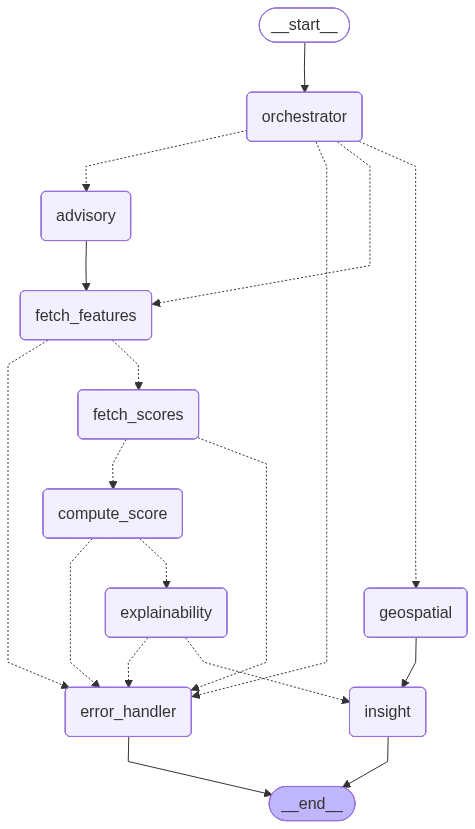

In [16]:
# Optional: Render graph as PNG (requires graphviz installed)
try:
    from IPython.display import Image, display
    img_bytes = compiled.get_graph().draw_mermaid_png()
    display(Image(img_bytes))
except Exception as e:
    print(f"Graph PNG rendering not available: {e}")
    print("Install graphviz or use the ASCII version above.")

---
## 9. 📊 Database Health Check

In [17]:
from sqlalchemy import text

async with factory() as db:
    # Total row count
    result = await db.execute(text("SELECT COUNT(*) FROM site_features"))
    total = result.scalar()
    print(f"Total sites in database: {total:,}")
    
    # State distribution
    result = await db.execute(text("""
        SELECT state, COUNT(*) as cnt
        FROM site_features
        GROUP BY state
        ORDER BY cnt DESC
        LIMIT 10
    """))
    print(f"\nTop 10 states by site count:")
    for row in result.fetchall():
        print(f"  {row[0]:25s} → {row[1]:>8,} sites")
    
    # Null check on Layer 7 scores
    result = await db.execute(text("""
        SELECT
            COUNT(*) FILTER (WHERE demand_score IS NULL) as demand_nulls,
            COUNT(*) FILTER (WHERE accessibility_score IS NULL) as access_nulls,
            COUNT(*) FILTER (WHERE risk_score IS NULL) as risk_nulls
        FROM site_features
    """))
    row = result.fetchone()
    print(f"\nLayer 7 score nulls:")
    print(f"  demand_score:        {row[0]:,}")
    print(f"  accessibility_score: {row[1]:,}")
    print(f"  risk_score:          {row[2]:,}")

2026-04-12 02:24:59,797 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-04-12 02:24:59 | INFO     | sqlalchemy.engine.Engine | BEGIN (implicit)
2026-04-12 02:24:59,801 INFO sqlalchemy.engine.Engine SELECT COUNT(*) FROM site_features
2026-04-12 02:24:59 | INFO     | sqlalchemy.engine.Engine | SELECT COUNT(*) FROM site_features
2026-04-12 02:24:59,804 INFO sqlalchemy.engine.Engine [generated in 0.00310s] ()
2026-04-12 02:24:59 | INFO     | sqlalchemy.engine.Engine | [generated in 0.00310s] ()
Total sites in database: 214,882
2026-04-12 02:24:59,919 INFO sqlalchemy.engine.Engine 
        SELECT state, COUNT(*) as cnt
        FROM site_features
        GROUP BY state
        ORDER BY cnt DESC
        LIMIT 10
    
2026-04-12 02:24:59 | INFO     | sqlalchemy.engine.Engine | 
        SELECT state, COUNT(*) as cnt
        FROM site_features
        GROUP BY state
        ORDER BY cnt DESC
        LIMIT 10
    
2026-04-12 02:24:59,921 INFO sqlalchemy.engine.Engine [generated in 0.00291s] (

---
## 10. 🧹 Cleanup

In [18]:
from core.database import dispose_engine

await dispose_engine()
print("Database engine disposed ✓")

2026-04-12 02:25:25 | INFO     | core.database | Database engine disposed
Database engine disposed ✓
